# Data Exploration and Reproducible Split - Matthew Shaver

Audit the local Dogs vs. Cats dataset and create reproducible split files.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'notebooks').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'notebooks').exists():
    raise FileNotFoundError('Open this notebook from the project repository.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)

Project root: C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam


## Local Dataset

The raw images stay in the local repository data folder and are not committed to GitHub.

In [3]:
DATASET_ROOT = PROJECT_ROOT / 'data' / 'dogs-vs-cats-classification'
SPLITS_DIR = PROJECT_ROOT / 'data' / 'splits'
CLASS_NAMES = ['cats', 'dogs']
SPLIT_NAMES = ['train', 'validation', 'test']

missing_folders = []
for split_name in SPLIT_NAMES:
    for class_name in CLASS_NAMES:
        class_folder = DATASET_ROOT / split_name / class_name
        if not class_folder.exists():
            missing_folders.append(class_folder)

if missing_folders:
    raise FileNotFoundError(
        'Place the Dogs vs. Cats dataset in data/dogs-vs-cats-classification.'
    )

print('Dataset root:', DATASET_ROOT)

Dataset root: C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam\data\dogs-vs-cats-classification


## Load Dataset Records

This notebook audits the Dogs vs. Cats dataset, verifies the existing folder structure, checks image quality, and creates reproducible train, validation, and test split files.

In [4]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Dataset exists:', DATASET_ROOT.exists())

Dataset exists: True


In [5]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png'}


def validate_class_coverage(records_table, class_names, table_name):
    expected_classes = set(class_names)
    observed_classes = set(records_table['label'])

    if observed_classes != expected_classes:
        raise ValueError(
            f'{table_name} must contain {sorted(expected_classes)}; '
            f'found {sorted(observed_classes)}.'
        )


def collect_image_records(dataset_root, class_names):
    records = []

    for image_path in sorted(dataset_root.rglob('*')):
        if not image_path.is_file():
            continue
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        label = None
        for class_name in class_names:
            if class_name in image_path.parts:
                label = class_name
                break

        if label is not None:
            records.append({
                'image_path': str(image_path.resolve()),
                'label': label,
            })

    if not records:
        raise ValueError(f'No images found under {dataset_root}')

    records_table = pd.DataFrame(records)
    validate_class_coverage(records_table, class_names, 'Dataset')
    return records_table


def create_stratified_splits(records, test_size, val_size, random_state):
    class_names = sorted(records['label'].unique())
    if len(class_names) < 2:
        raise ValueError('At least two classes are required for splitting.')

    train_val_records, test_records = train_test_split(
        records,
        test_size=test_size,
        stratify=records['label'],
        random_state=random_state,
    )

    train_records, val_records = train_test_split(
        train_val_records,
        test_size=val_size,
        stratify=train_val_records['label'],
        random_state=random_state,
    )

    train_records = train_records.reset_index(drop=True)
    val_records = val_records.reset_index(drop=True)
    test_records = test_records.reset_index(drop=True)

    validate_class_coverage(train_records, class_names, 'Training split')
    validate_class_coverage(val_records, class_names, 'Validation split')
    validate_class_coverage(test_records, class_names, 'Test split')
    return train_records, val_records, test_records


def save_split_csvs(train_records, val_records, test_records, output_dir):
    output_dir.mkdir(parents=True, exist_ok=True)

    split_paths = {
        'train': output_dir / 'train_split.csv',
        'validation': output_dir / 'val_split.csv',
        'test': output_dir / 'test_split.csv',
    }

    train_records.to_csv(split_paths['train'], index=False)
    val_records.to_csv(split_paths['validation'], index=False)
    test_records.to_csv(split_paths['test'], index=False)
    return split_paths

In [6]:
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f'Dataset not found at {DATASET_ROOT}.')

records = collect_image_records(DATASET_ROOT, CLASS_NAMES)
class_counts = records['label'].value_counts().sort_index()

expected_classes = set(CLASS_NAMES)
observed_classes = set(class_counts.index)
if observed_classes != expected_classes:
    raise ValueError(
        f'Dataset must contain {sorted(expected_classes)}; '
        f'found {sorted(observed_classes)}.'
    )

display(records.head())
display(class_counts)

,image_path,label
0,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,cats
1,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,cats
2,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,cats
3,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,cats
4,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,cats


label
cats    12470
dogs    12458
Name: count, dtype: int64

## Explore the Dataset

These quick checks show the class balance, a small sample of labeled images, and the image sizes in the local dataset.

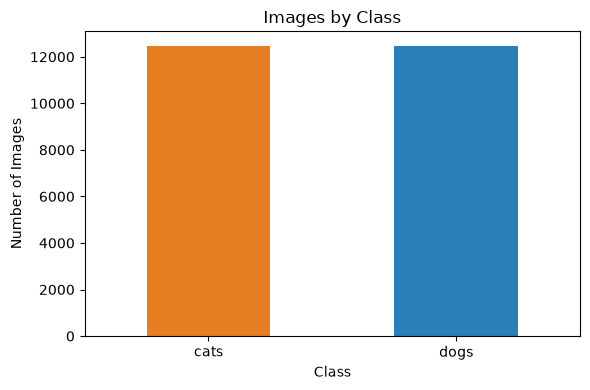

In [9]:
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['#e67e22', '#2980b9'])
plt.title('Images by Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

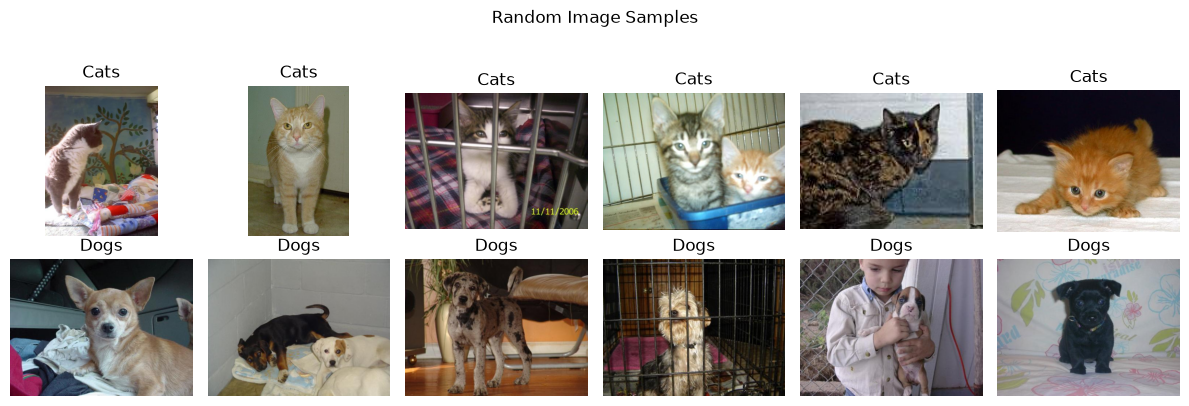

In [10]:
sample_images = records.groupby('label', group_keys=False).sample(
    n=min(6, records['label'].value_counts().min()),
    random_state=SEED,
)

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for axis, (_, record) in zip(axes.flat, sample_images.iterrows()):
    with Image.open(record['image_path']) as image:
        axis.imshow(image.convert('RGB'))
    axis.set_title(record['label'].title())
    axis.axis('off')

for axis in axes.flat[len(sample_images):]:
    axis.axis('off')

plt.suptitle('Random Image Samples', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
image_details = []
for image_path in records['image_path'].sample(n=min(100, len(records)), random_state=SEED):
    with Image.open(image_path) as image:
        width, height = image.size
        image_details.append({'width': width, 'height': height, 'mode': image.mode})

image_details = pd.DataFrame(image_details)
print('Image details from a random sample of', len(image_details), 'images')
display(image_details.describe())
display(image_details['mode'].value_counts().rename_axis('mode').to_frame('count'))

Image details from a random sample of 100 images


,width,height
count,100.000000,100.000000
mean,423.720000,354.820000
std,107.587886,93.805664
min,90.000000,82.000000
25%,349.500000,315.000000
50%,500.000000,375.000000
75%,500.000000,388.750000
max,500.000000,500.000000


,count
mode,
RGB,100


: 

In [7]:
if records.empty:
    print('Skipping split generation because no images are available.')
    train_records = pd.DataFrame(columns=['image_path', 'label'])
    val_records = pd.DataFrame(columns=['image_path', 'label'])
    test_records = pd.DataFrame(columns=['image_path', 'label'])
    split_paths = None
    summary = pd.DataFrame({'split': ['train', 'validation', 'test'], 'count': [0, 0, 0]})
else:
    train_records, val_records, test_records = create_stratified_splits(
        records=records,
        test_size=0.30,
        val_size=0.15,
        random_state=42,
    )

    expected_classes = set(CLASS_NAMES)
    split_tables = {
        'training': train_records,
        'validation': val_records,
        'test': test_records,
    }
    for split_name, split_table in split_tables.items():
        observed_classes = set(split_table['label'])
        if observed_classes != expected_classes:
            raise ValueError(
                f'{split_name.title()} split must contain {sorted(expected_classes)}; '
                f'found {sorted(observed_classes)}.'
            )

    split_paths = save_split_csvs(train_records, val_records, test_records, SPLITS_DIR)
    summary = pd.DataFrame({
        'split': ['train', 'validation', 'test'],
        'count': [len(train_records), len(val_records), len(test_records)],
        'cats': [
            int((train_records['label'] == 'cats').sum()),
            int((val_records['label'] == 'cats').sum()),
            int((test_records['label'] == 'cats').sum()),
        ],
        'dogs': [
            int((train_records['label'] == 'dogs').sum()),
            int((val_records['label'] == 'dogs').sum()),
            int((test_records['label'] == 'dogs').sum()),
        ],
    })

split_paths, summary

({'train': WindowsPath('C:/Users/Matt Shaver/OneDrive/Desktop/DSBA-6165-Sum-2026-Take-Home-Exam/data/splits/train_split.csv'),
  'validation': WindowsPath('C:/Users/Matt Shaver/OneDrive/Desktop/DSBA-6165-Sum-2026-Take-Home-Exam/data/splits/val_split.csv'),
  'test': WindowsPath('C:/Users/Matt Shaver/OneDrive/Desktop/DSBA-6165-Sum-2026-Take-Home-Exam/data/splits/test_split.csv')},
         split  count  cats  dogs
 0       train  14831  7419  7412
 1  validation   2618  1310  1308
 2        test   7479  3741  3738)

In [8]:
def check_image(path_str):
    try:
        with Image.open(path_str) as image:
            image.verify()
        with Image.open(path_str) as image:
            return image.size, image.mode, None
    except (UnidentifiedImageError, OSError) as exc:
        return None, None, str(exc)

if records.empty:
    print('Skipping image integrity checks because no images were loaded.')
    sample_checks = pd.DataFrame(columns=['image_path', 'label', 'size', 'mode', 'error'])
else:
    sample_checks = records.sample(n=min(20, len(records)), random_state=42).copy()
    sample_checks[['size', 'mode', 'error']] = sample_checks['image_path'].apply(lambda p: pd.Series(check_image(p)))

sample_checks

,image_path,label,size,mode,error
5719,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,cats,"(400, 366)",RGB,None
8918,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,cats,"(480, 289)",RGB,None
9504,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,cats,"(500, 375)",RGB,None
12284,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,cats,"(200, 134)",RGB,None
5709,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,cats,"(452, 500)",RGB,None
16296,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,dogs,"(360, 346)",RGB,None
8936,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,cats,"(500, 321)",RGB,None
1087,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,cats,"(500, 331)",RGB,None
3111,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,cats,"(424, 500)",RGB,None
13043,C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-616...,dogs,"(250, 250)",RGB,None
